In [20]:
%pip install network
%pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\LLM\cuda\Scripts\python.exe -m pip install --upgrade pip' command.


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\LLM\cuda\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import networkx as nx #图数据挖掘
import numpy as np #数据分析
import random
import pandas as pd
#数据可视化
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
plt.rcParams['font.sans-serif']=['SimHei'] #正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

In [4]:
df = pd.read_csv('data/triples.csv')


In [5]:
df

,head,tail,relation,label
0,金蝉子,唐僧,past_life,前世
1,孙悟空,唐僧,apprentice,徒弟
2,猪八戒,唐僧,apprentice,徒弟
3,沙僧,唐僧,apprentice,徒弟
4,白龙马,唐僧,apprentice,徒弟
...,...,...,...,...
104,毗蓝婆菩萨,昴日星官,mother,母亲
105,嫦娥,后羿,wife,妻
106,敖摩昂,敖闰,son,儿
107,哪吒,李靖,son,儿


In [7]:
edges = [edge for edge in zip(df['head'],df['tail'])]
G = nx.DiGraph()
G.add_edges_from(edges)

In [9]:
print(G)

DiGraph with 104 nodes and 109 edges


In [10]:
G.nodes

NodeView(('金蝉子', '唐僧', '孙悟空', '猪八戒', '沙僧', '白龙马', '陈光蕊', '殷温娇', '法明和尚', '李世民', '殷开山', '菩提老祖', '镇元子', '牛魔王', '蛟魔王', '鹏魔王', '狮驼王', '猕猴王', '禺狨王', '天蓬元帅', '卵二姐', '高翠兰', '卷帘大将', '西海龙王', '西海龙母', '敖摩昂太子', '西海龙女', '李渊', '李建成', '李元吉', '王珪', '秦琼', '萧瑀', '傅奕', '魏征', '李玉英', '房玄龄', '杜如晦', '徐世绩', '徐茂公', '许敬宗', '马三宝', '段志贤', '程咬金', '虞世南', '张道源', '张士衡', '高太公', '高香兰', '高玉兰', '寇洪', '寇梁', '宼栋', '袁守诚', '袁天罡', '李靖', '木吒', '哪吒', '金吒', '正元龙', '观音菩萨', '二十四路诸天', '守山大神', '善财童子', '捧珠龙女', '如来', '红孩儿', '黑风怪', '黄风怪', '灵吉菩萨', '黄毛貂鼠', '金角', '太上老君', '银角', '铁扇公主', '九尾狐狸', '狐阿七', '鼍龙怪', '西海龙王太子', '灵感大王', '独角兕大王', '玉面公主', '金毛犼', '黄眉道童', '弥勒佛', '百眼魔君', '毗蓝婆菩萨', '青狮', '文殊菩萨', '白象', '普贤菩萨', '大鹏金翅雕', '九头狮子', '太乙救苦天尊', '玉兔精', '嫦娥', '白鹿精', '南极寿星', '黄眉大王', '东来佛祖笑和尚', '昴日星官', '后羿', '敖摩昂', '敖闰'))

In [11]:
len(G)

104

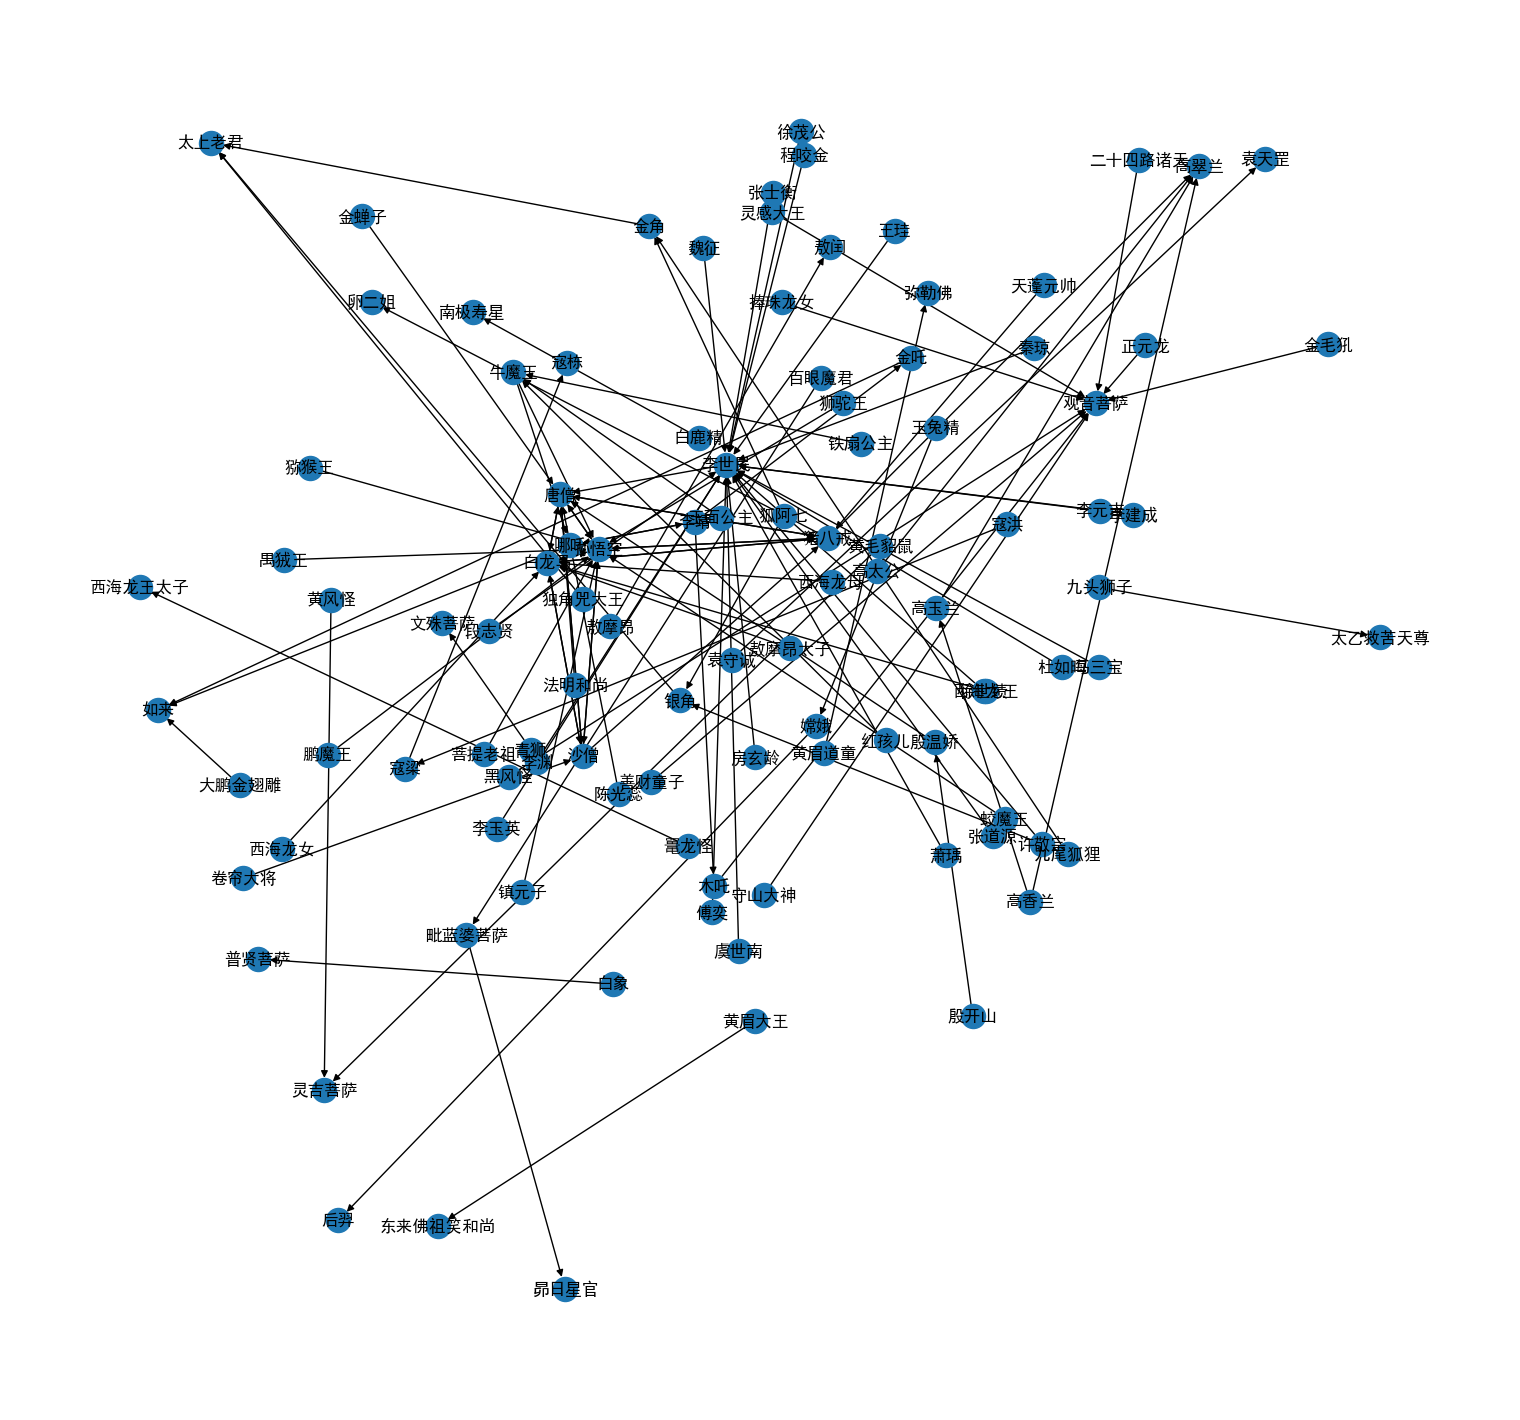

In [15]:
plt.figure(figsize=(15,14))
pos = nx.spring_layout(G,iterations=3,seed=5) #A dictionary with nodes as keys and positions as values.
nx.draw(G,pos,with_labels=True)
plt.show()

In [16]:
nx.pagerank?

Signature:     
nx.pagerank(
    G,
    alpha=0.85,
    personalization=None,
    max_iter=100,
    tol=1e-06,
    nstart=None,
    weight='weight',
    dangling=None,
    *,
    backend=None,
    **backend_kwargs,
)
Call signature: nx.pagerank(*args, backend=None, **kwargs)
Type:           _dispatch
String form:    <networkx.utils.backends._dispatch object at 0x000002597F703D30>
File:           d:\llm\cuda\lib\site-packages\networkx\algorithms\link_analysis\pagerank_alg.py
Docstring:     
Returns the PageRank of the nodes in the graph.

PageRank computes a ranking of the nodes in the graph G based on
the structure of the incoming links. It was originally designed as
an algorithm to rank web pages.

Parameters
----------
G : graph
  A NetworkX graph.  Undirected graphs will be converted to a directed
  graph with two directed edges for each undirected edge.

alpha : float, optional
  Damping parameter for PageRank, default=0.85.

personalization: dict, optional
  The "personalization v

In [21]:
pagerank = nx.pagerank(G, #NetworkX graph 有向图，如果是无向图则自动转为双向有向图
                       alpha=0.85, #Damping factor
                       personalization=None, #是否开启Personalization PageRank，随机传送至指定节点集合的概率更高或更低
                       max_iter=100, #最大迭代次数
                       tol=1e-06, #判定收敛的误差
                       nstart=None, #每个节点初始PageRank值
                       dangling=None #Dead End 死胡同节点
                       )

In [22]:
pagerank

{'金蝉子': 0.0028889203144616088,
 '唐僧': 0.13349105557884888,
 '孙悟空': 0.10498354112014094,
 '猪八戒': 0.09247797536009736,
 '沙僧': 0.07627154154696374,
 '白龙马': 0.09531260474698808,
 '陈光蕊': 0.0028889203144616088,
 '殷温娇': 0.005344620286308959,
 '法明和尚': 0.0028889203144616088,
 '李世民': 0.052002919751408624,
 '殷开山': 0.0028889203144616088,
 '菩提老祖': 0.0028889203144616088,
 '镇元子': 0.0028889203144616088,
 '牛魔王': 0.010256020230003658,
 '蛟魔王': 0.0028889203144616088,
 '鹏魔王': 0.0028889203144616088,
 '狮驼王': 0.0028889203144616088,
 '猕猴王': 0.0028889203144616088,
 '禺狨王': 0.0028889203144616088,
 '天蓬元帅': 0.0028889203144616088,
 '卵二姐': 0.01860884001045803,
 '高翠兰': 0.02579183411604112,
 '卷帘大将': 0.0028889203144616088,
 '西海龙王': 0.0028889203144616088,
 '西海龙母': 0.0028889203144616088,
 '敖摩昂太子': 0.0028889203144616088,
 '西海龙女': 0.0028889203144616088,
 '李渊': 0.0028889203144616088,
 '李建成': 0.0028889203144616088,
 '李元吉': 0.0028889203144616088,
 '王珪': 0.0028889203144616088,
 '秦琼': 0.0028889203144616088,
 '萧瑀': 0.002888920314

In [25]:
sorted(pagerank.items(),key=lambda x:x[1],reverse = True)

[('唐僧', 0.13349105557884888),
 ('孙悟空', 0.10498354112014094),
 ('白龙马', 0.09531260474698808),
 ('猪八戒', 0.09247797536009736),
 ('沙僧', 0.07627154154696374),
 ('李世民', 0.052002919751408624),
 ('观音菩萨', 0.026625716774094633),
 ('高翠兰', 0.02579183411604112),
 ('卵二姐', 0.01860884001045803),
 ('太上老君', 0.014430996933862522),
 ('如来', 0.013334300311185142),
 ('牛魔王', 0.010256020230003658),
 ('哪吒', 0.009171370913926254),
 ('灵吉菩萨', 0.007800320258156309),
 ('宼栋', 0.007432108638238391),
 ('昴日星官', 0.007432108638238391),
 ('后羿', 0.007432108638238391),
 ('李靖', 0.006787403654483575),
 ('殷温娇', 0.005344620286308959),
 ('寇梁', 0.005344620286308959),
 ('袁天罡', 0.005344620286308959),
 ('金角', 0.005344620286308959),
 ('银角', 0.005344620286308959),
 ('西海龙王太子', 0.005344620286308959),
 ('弥勒佛', 0.005344620286308959),
 ('毗蓝婆菩萨', 0.005344620286308959),
 ('文殊菩萨', 0.005344620286308959),
 ('普贤菩萨', 0.005344620286308959),
 ('太乙救苦天尊', 0.005344620286308959),
 ('嫦娥', 0.005344620286308959),
 ('南极寿星', 0.005344620286308959),
 ('东来佛祖笑和尚'

In [26]:
#用节点尺寸可视化PageRank的值
node_sizes = (np.array(list(pagerank.values()))*8000).astype(int)
node_sizes

array([  23, 1067,  839,  739,  610,  762,   23,   42,   23,  416,   23,
         23,   23,   82,   23,   23,   23,   23,   23,   23,  148,  206,
         23,   23,   23,   23,   23,   23,   23,   23,   23,   23,   23,
         23,   23,   23,   23,   23,   23,   23,   23,   23,   23,   23,
         23,   23,   23,   23,   23,   32,   23,   42,   59,   23,   42,
         54,   38,   73,   38,   23,  213,   23,   23,   23,   23,  106,
         23,   23,   23,   62,   23,   42,  115,   42,   23,   23,   23,
         23,   42,   23,   23,   23,   23,   23,   42,   23,   42,   23,
         42,   23,   42,   23,   23,   42,   23,   42,   23,   42,   23,
         42,   59,   59,   23,   42])

In [27]:
M = G.number_of_edges()
edge_colors = range(2,M+2)

AttributeError: 'function' object has no attribute 'set_axis_off'

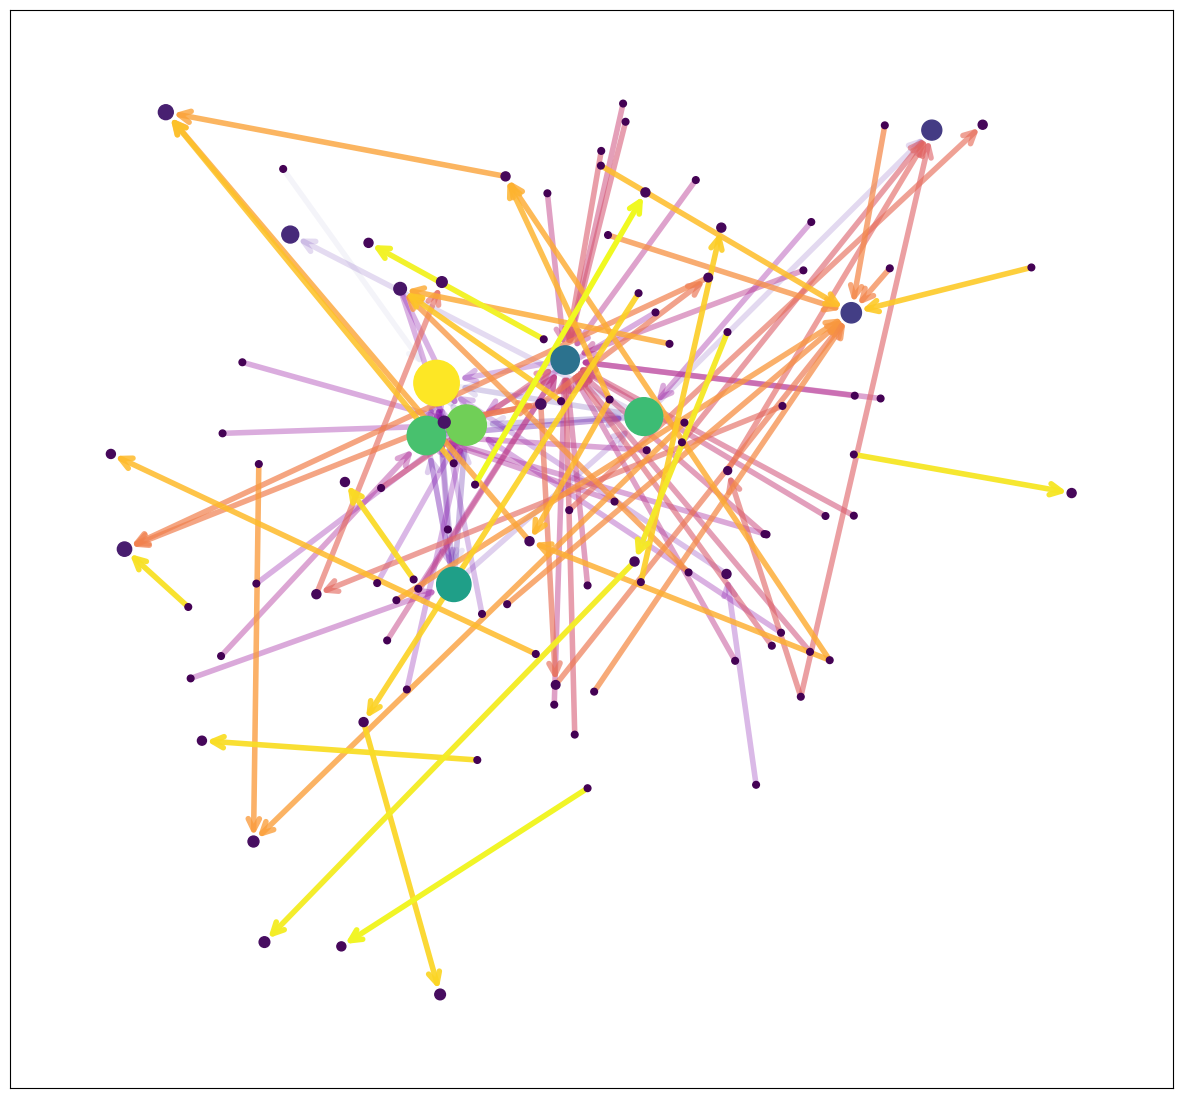

In [30]:
plt.figure(figsize=(15,14))
nodes = nx.draw_networkx_nodes(G,pos,node_size=node_sizes,node_color=node_sizes)
edges = nx.draw_networkx_edges(
    G,
    pos,
    node_size=node_sizes,
    arrowstyle="->",
    arrowsize=20,
    edge_color=edge_colors,
    edge_cmap=plt.cm.plasma,
    width=4
)
#每个连接的透明度
edge_alphas = [(5+i)/(M+4) for i in range(M)]
for i in range(M):
    edges[i].set_alpha(edge_alphas[i])

ax = plt.gca
ax.set_axis_off()
plt.show()